

# Data Preparation & Exploratory Data Analysis

## Project Goal

The objective of this notebook is to prepare the e-commerce dataset for analysis and perform an exploratory data analysis (EDA) to understand user behavior, product characteristics, and overall event distribution.

The insights obtained here will serve as the foundation for the funnel analysis and customer behavior analysis in the following notebooks.


## Import Libraries

In [41]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## Load Prepared Dataset

The cleaned dataset consists of four relational tables:

- events
- products
- users
- sessions

These tables were created during the preprocessing stage.


In [ ]:

events = pd.read_csv("events.csv")
products = pd.read_csv("products.csv")
users = pd.read_csv("users.csv")
sessions = pd.read_csv("sessions.csv")

## Dataset Overview

In [ ]:
events.shape
products.shape
users.shape
sessions.shape

(182503, 2)

## Preview of the Data

In [ ]:
events.head()
products.head()
users.head()
sessions.head()

,user_session,user_id
0,73e0d0ba-31ac-4969-99b6-99384c7befd5,513862142
1,e41aa5ae-cdd3-4028-aafe-2a223a78993a,529291197
2,a4adcef6-80d7-44d5-8e6b-deb3799ae13f,543844376
3,8ca640b8-7cab-41d2-a7d5-b0335a675ca5,534177598
4,04acae74-f5a9-4407-bca3-740e3263a1c0,520248589


## Data Types

In [ ]:
events.info()
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500000 entries, 0 to 499999
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   event_time    500000 non-null  object
 1   event_type    500000 non-null  object
 2   product_id    500000 non-null  int64 
 3   user_id       500000 non-null  int64 
 4   user_session  500000 non-null  object
dtypes: int64(2), object(3)
memory usage: 19.1+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52632 entries, 0 to 52631
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   product_id     52632 non-null  int64  
 1   category_id    52632 non-null  int64  
 2   category_code  26359 non-null  object 
 3   brand          40432 non-null  object 
 4   price          52632 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 2.0+ MB


## Missing Values

In [ ]:
events.isna().sum()
products.isna().sum()

,0
product_id,0
category_id,0
category_code,26273
brand,12200
price,0


In [ ]:
events["event_type"].value_counts()
events["user_id"].nunique()
events["product_id"].nunique()
events["user_session"].nunique()

182502

In [ ]:
events["event_type"].value_counts()

,count
event_type,
view,483943
purchase,8746
cart,7311


## Merge Tables

The events table is merged with the products table to enrich each user event with product information such as brand, category, and price.

In [ ]:
df = events.merge(
    products,
    on="product_id",
    how="left"
)

df.head()

,event_time,event_type,product_id,user_id,user_session,date,hour,weekday,category_id,category_code,brand,price
0,2019-11-01 13:06:48+00:00,view,1801539,513862142,73e0d0ba-31ac-4969-99b6-99384c7befd5,2019-11-01,13,Friday,2053013554415534427,electronics.video.tv,lg,406.70
1,2019-11-01 14:54:06+00:00,view,1004795,529291197,e41aa5ae-cdd3-4028-aafe-2a223a78993a,2019-11-01,14,Friday,2053013555631882655,electronics.smartphone,xiaomi,218.54
2,2019-11-01 14:34:54+00:00,view,14701260,543844376,a4adcef6-80d7-44d5-8e6b-deb3799ae13f,2019-11-01,14,Friday,2053013557133443581,furniture.living_room.cabinet,NaN,174.78
3,2019-11-01 13:08:57+00:00,view,14700105,534177598,8ca640b8-7cab-41d2-a7d5-b0335a675ca5,2019-11-01,13,Friday,2053013557133443581,furniture.living_room.cabinet,NaN,385.85
4,2019-11-01 11:27:41+00:00,view,1004965,520248589,04acae74-f5a9-4407-bca3-740e3263a1c0,2019-11-01,11,Friday,2053013555631882655,electronics.smartphone,oppo,900.87


# Exploratory Data Analysis

In [ ]:
print(f"Total events: {len(df):,}")
print(f"Unique users: {df['user_id'].nunique():,}")
print(f"Unique sessions: {df['user_session'].nunique():,}")
print(f"Unique products: {df['product_id'].nunique():,}")
print(f"Unique brands: {df['brand'].nunique():,}")
print(f"Unique categories: {df['category_code'].nunique():,}")

Total events: 500,000
Unique users: 138,462
Unique sessions: 182,502
Unique products: 52,632
Unique brands: 2,466
Unique categories: 123


In [ ]:
event_counts = df["event_type"].value_counts().reset_index()
event_counts.columns = ["event_type", "count"]

event_counts

,event_type,count
0,view,483943
1,purchase,8746
2,cart,7311


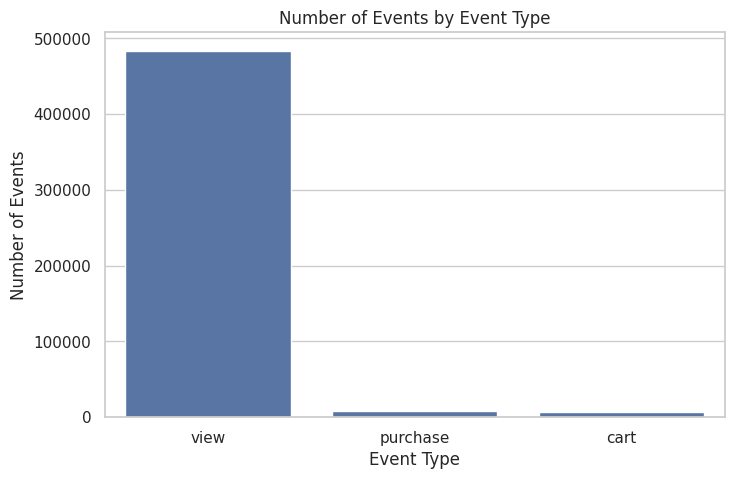

In [ ]:
plt.figure(figsize=(8, 5))
sns.barplot(data=event_counts, x="event_type", y="count")

plt.title("Number of Events by Event Type")
plt.xlabel("Event Type")
plt.ylabel("Number of Events")
plt.show()

In [ ]:
events_by_day = df.groupby("date").size().reset_index(name="events")

events_by_day.head()

,date,events
0,2019-11-01,500000


In [ ]:
events_by_hour = df.groupby("hour").size().reset_index(name="events")

events_by_hour

,hour,events
0,0,5147
1,1,6629
2,2,15482
3,3,23386
4,4,29235
5,5,35052
6,6,36263
7,7,38129
8,8,38080
9,9,36421


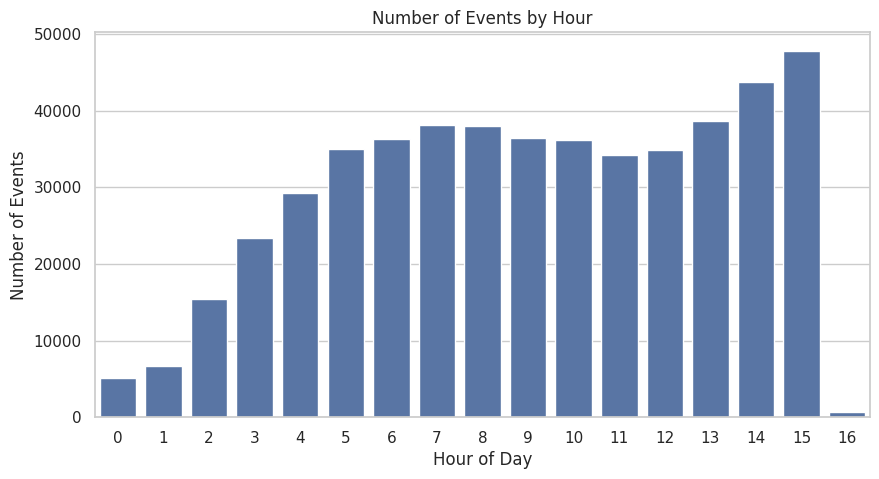

In [ ]:
plt.figure(figsize=(10, 5))
sns.barplot(data=events_by_hour, x="hour", y="events")

plt.title("Number of Events by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Events")
plt.show()

In [ ]:
top_categories = (
    df["category_code"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_categories.columns = ["category_code", "events"]

top_categories

,category_code,events
0,electronics.smartphone,135067
1,electronics.clocks,14740
2,electronics.video.tv,14723
3,computers.notebook,14166
4,electronics.audio.headphone,13502
5,apparel.shoes,10413
6,appliances.kitchen.washer,10350
7,appliances.kitchen.refrigerators,9946
8,appliances.environment.vacuum,9521
9,furniture.living_room.cabinet,7049


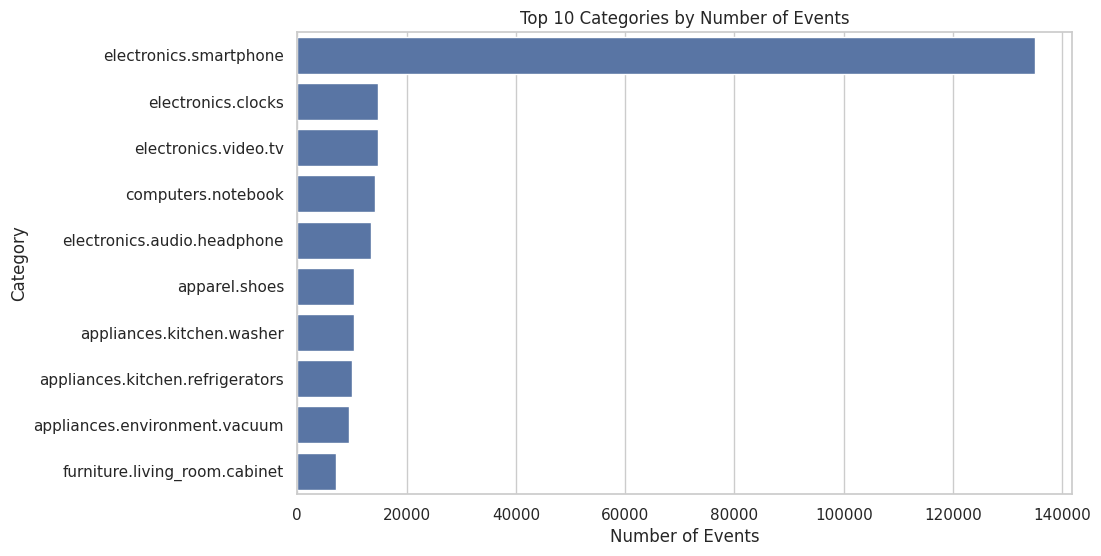

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_categories, y="category_code", x="events")

plt.title("Top 10 Categories by Number of Events")
plt.xlabel("Number of Events")
plt.ylabel("Category")
plt.show()

In [ ]:
top_brands = (
    df["brand"]
    .value_counts()
    .head(10)
    .reset_index()
)

top_brands.columns = ["brand", "events"]

top_brands

,brand,events
0,samsung,62968
1,apple,49859
2,xiaomi,36137
3,huawei,12007
4,lucente,7884
5,oppo,7006
6,lg,6609
7,bosch,6137
8,cordiant,5718
9,sony,5673


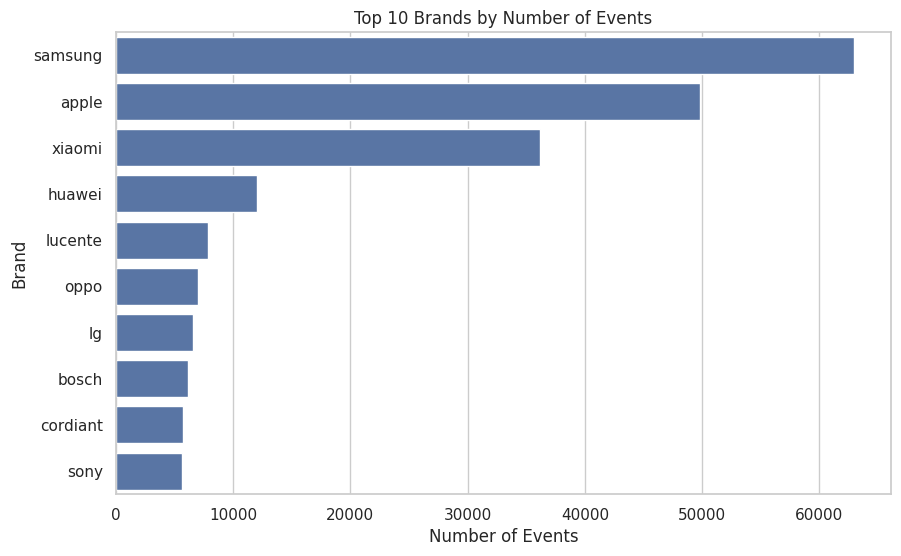

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=top_brands, y="brand", x="events")

plt.title("Top 10 Brands by Number of Events")
plt.xlabel("Number of Events")
plt.ylabel("Brand")
plt.show()

In [ ]:
df["price"].describe()

,price
count,500000.000000
mean,292.204759
std,347.822302
min,0.000000
25%,69.500000
50%,172.200000
75%,361.970000
max,2574.070000


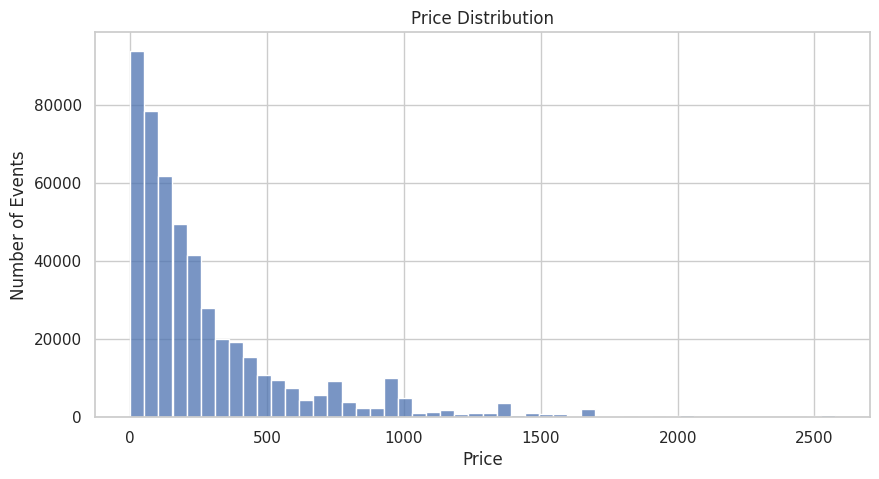

In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(df["price"], bins=50)

plt.title("Price Distribution")
plt.xlabel("Price")
plt.ylabel("Number of Events")
plt.show()

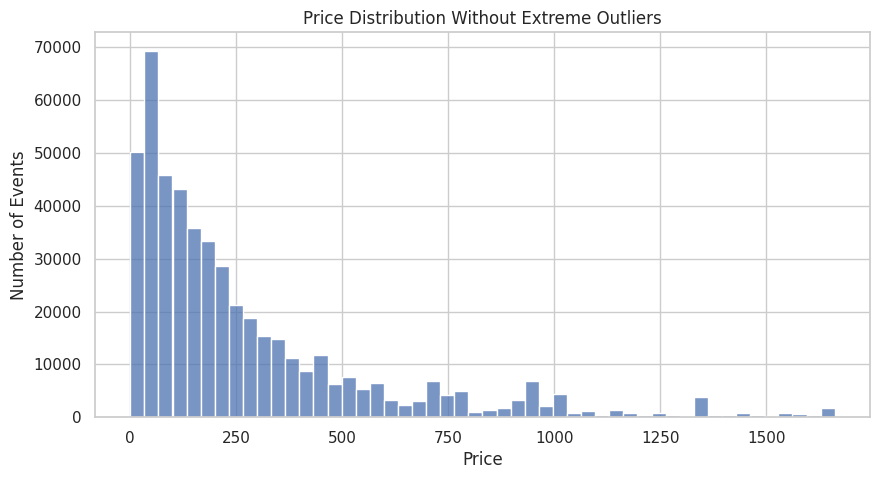

In [ ]:
price_99 = df["price"].quantile(0.99)

df_price_filtered = df[df["price"] <= price_99]

plt.figure(figsize=(10, 5))
sns.histplot(df_price_filtered["price"], bins=50)

plt.title("Price Distribution Without Extreme Outliers")
plt.xlabel("Price")
plt.ylabel("Number of Events")
plt.show()

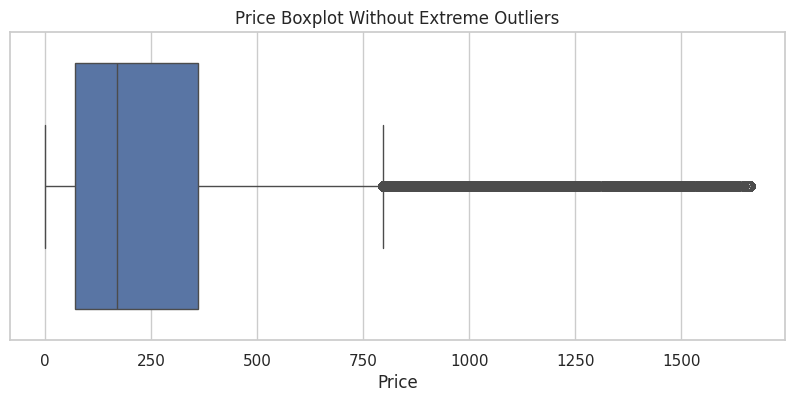

In [ ]:
plt.figure(figsize=(10, 4))
sns.boxplot(x=df_price_filtered["price"])

plt.title("Price Boxplot Without Extreme Outliers")
plt.xlabel("Price")
plt.show()

In [ ]:
purchases_by_category = (
    df[df["event_type"] == "purchase"]
    ["category_code"]
    .value_counts()
    .head(10)
    .reset_index()
)

purchases_by_category.columns = ["category_code", "purchases"]

purchases_by_category

,category_code,purchases
0,electronics.smartphone,4088
1,electronics.audio.headphone,351
2,electronics.video.tv,264
3,electronics.clocks,181
4,appliances.kitchen.washer,171
5,computers.notebook,161
6,appliances.environment.vacuum,118
7,appliances.kitchen.refrigerators,116
8,computers.desktop,59
9,electronics.tablet,48


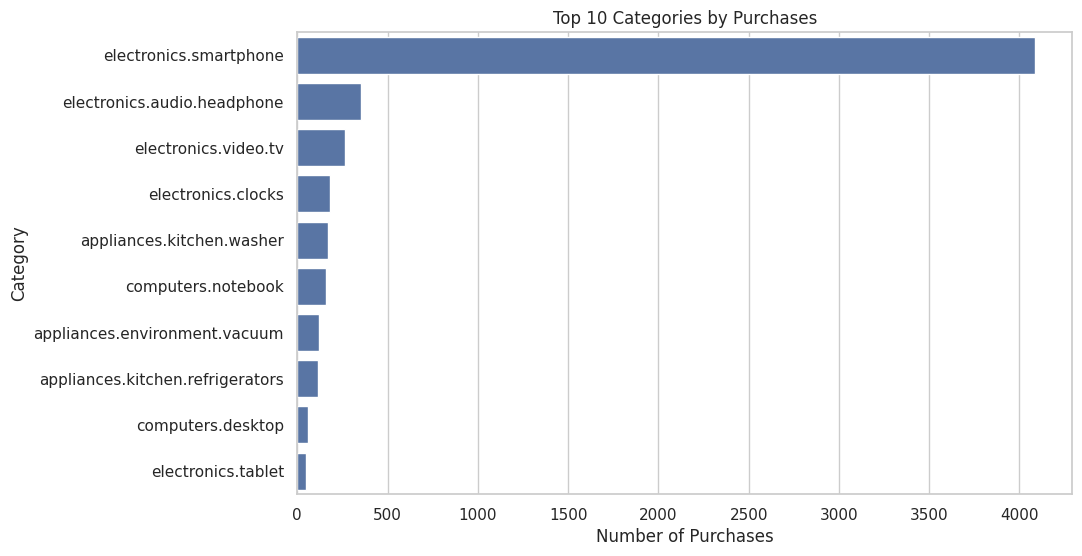

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=purchases_by_category, y="category_code", x="purchases")

plt.title("Top 10 Categories by Purchases")
plt.xlabel("Number of Purchases")
plt.ylabel("Category")
plt.show()

In [ ]:
purchases_by_brand = (
    df[df["event_type"] == "purchase"]
    ["brand"]
    .value_counts()
    .head(10)
    .reset_index()
)

purchases_by_brand.columns = ["brand", "purchases"]

purchases_by_brand

,brand,purchases
0,samsung,2064
1,apple,1769
2,xiaomi,616
3,huawei,241
4,cordiant,187
5,oppo,152
6,lucente,137
7,nokian,101
8,lg,91
9,sony,85


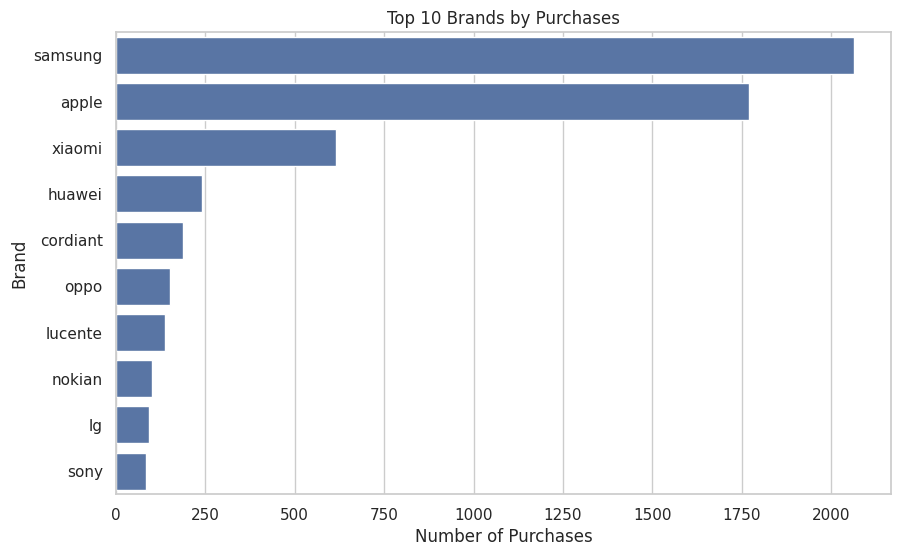

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(data=purchases_by_brand, y="brand", x="purchases")

plt.title("Top 10 Brands by Purchases")
plt.xlabel("Number of Purchases")
plt.ylabel("Brand")
plt.show()

# Key Findings

- Product views represent the majority of all recorded events.
- User activity changes significantly throughout the day.
- A limited number of brands and categories account for most interactions.
- Product prices are heavily right-skewed due to expensive outliers.
- The exploratory analysis provides a solid basis for investigating the conversion funnel and customer behavior.